In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jakewright/9000-tickers-of-stock-market-data-full-history/all_stock_data.parquet
/kaggle/input/datasets/jakewright/9000-tickers-of-stock-market-data-full-history/all_stock_data.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/jakewright/9000-tickers-of-stock-market-data-full-history/all_stock_data.csv')

In [3]:
ticker_freq = (
    data['Ticker']
    .value_counts()
    .reset_index()
)

ticker_freq.columns = ['Ticker', 'Frequency']

print(ticker_freq)

     Ticker  Frequency
0       MMM      15819
1       DIS      15819
2       XRX      15819
3        MO      15819
4       CNP      15819
...     ...        ...
9310  SHCRW          1
9311  CHKEW          1
9312  CHKEZ          1
9313    INR          1
9314   TRLI          1

[9315 rows x 2 columns]


In [4]:
df_mmm = data[data['Ticker'] == 'MMM']

In [5]:
df_mmm = df_mmm.reset_index(drop=True)
print(len(df_mmm))
df_mmm.head(10)

15819


,Date,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1962-01-02,MMM,0.0,0.541891,0.525953,0.529937,254509.0,0.0,0.0
1,1962-01-03,MMM,0.0,0.533921,0.520972,0.533921,505190.0,0.0,0.0
2,1962-01-04,MMM,0.0,0.542886,0.533921,0.533921,254509.0,0.0,0.0
3,1962-01-05,MMM,0.0,0.531930,0.517984,0.519976,376979.0,0.0,0.0
4,1962-01-08,MMM,0.0,0.520972,0.513999,0.516987,399942.0,0.0,0.0
5,1962-01-09,MMM,0.0,0.520972,0.514995,0.516987,376979.0,0.0,0.0
6,1962-01-10,MMM,0.0,0.515991,0.510015,0.511011,304262.0,0.0,0.0
7,1962-01-11,MMM,0.0,0.513999,0.497065,0.509018,269818.0,0.0,0.0
8,1962-01-12,MMM,0.0,0.515991,0.499057,0.499057,692723.0,0.0,0.0
9,1962-01-15,MMM,0.0,0.505034,0.499057,0.504038,252595.0,0.0,0.0


## Clean and adjust the data

In [6]:
df_mmm.info()

df_mmm.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15819 entries, 0 to 15818
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          15819 non-null  object 
 1   Ticker        15819 non-null  object 
 2   Open          15819 non-null  float64
 3   High          15819 non-null  float64
 4   Low           15819 non-null  float64
 5   Close         15819 non-null  float64
 6   Volume        15819 non-null  float64
 7   Dividends     15819 non-null  float64
 8   Stock Splits  15819 non-null  float64
dtypes: float64(7), object(2)
memory usage: 1.1+ MB


Date            0
Ticker          0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

#### Convert to date-time

In [7]:
df_mmm = df_mmm.sort_values('Date')
df_mmm = df_mmm.reset_index(drop=True)
df_mmm = df_mmm.drop_duplicates()

In [8]:
df_mmm[df_mmm.isna().any(axis=1)]

,Date,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits


In [9]:
(df_mmm[['Open','High','Low','Close']] <= 0).sum()

Open     1987
High        0
Low         0
Close       0
dtype: int64

In [10]:
(df_mmm['Volume'] < 0).sum()

np.int64(0)

#### Verify High/Low consistency

In [11]:
bad = df_mmm[
    (df_mmm['High'] < df_mmm['Open']) |
    (df_mmm['High'] < df_mmm['Close']) |
    (df_mmm['Low'] > df_mmm['Open']) |
    (df_mmm['Low'] > df_mmm['Close'])
]

#### Check for abnormaml jumps and handle stock splits

In [12]:
df_mmm['Return'] = df_mmm['Close'].pct_change()
df_mmm[df_mmm['Return'].abs() > 0.5]

,Date,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits,Return


In [13]:
df_mmm[df_mmm["Stock Splits"] != 0]

,Date,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits,Return
2610,1972-06-16,MMM,1.283438,1.283438,1.270917,1.283438,204755.0,0.0,2.0,-0.001624
6397,1987-06-16,MMM,4.410229,4.418175,4.275141,4.410229,3009136.0,0.0,2.0,0.026827
8122,1994-04-11,MMM,8.559790,8.664177,8.538912,8.622422,1810744.0,0.0,2.0,0.008547
10508,2003-09-30,MMM,32.589745,32.762251,32.142160,32.202770,6220635.0,0.0,2.0,-0.017077


In [14]:
(df_mmm["Stock Splits"] != 0).sum()

np.int64(4)

In [15]:
df_mmm["Stock Splits"].value_counts()

Stock Splits
0.0    15815
2.0        4
Name: count, dtype: int64

In [16]:
split_dates = df_mmm[df_mmm["Stock Splits"] != 0].index

for idx in split_dates:
    print(df_mmm.iloc[idx-3:idx+4][["Date","Close","Stock Splits"]])

            Date     Close  Stock Splits
2607  1972-06-13  1.243787           0.0
2608  1972-06-14  1.262570           0.0
2609  1972-06-15  1.285525           0.0
2610  1972-06-16  1.283438           2.0
2611  1972-06-19  1.268830           0.0
2612  1972-06-20  1.262570           0.0
2613  1972-06-21  1.308482           0.0
            Date     Close  Stock Splits
6394  1987-06-11  4.255276           0.0
6395  1987-06-12  4.298979           0.0
6396  1987-06-15  4.295007           0.0
6397  1987-06-16  4.410229           2.0
6398  1987-06-17  4.410229           0.0
6399  1987-06-18  4.410229           0.0
6400  1987-06-19  4.386390           0.0
            Date     Close  Stock Splits
8119  1994-04-06  8.267503           0.0
8120  1994-04-07  8.340576           0.0
8121  1994-04-08  8.549351           0.0
8122  1994-04-11  8.622422           2.0
8123  1994-04-12  8.518039           0.0
8124  1994-04-13  8.413653           0.0
8125  1994-04-14  8.267503           0.0
             Dat

In [17]:
split_days = df_mmm[df_mmm["Stock Splits"] != 0]

print(split_days[["Date","Close","Return","Stock Splits"]])

             Date      Close    Return  Stock Splits
2610   1972-06-16   1.283438 -0.001624           2.0
6397   1987-06-16   4.410229  0.026827           2.0
8122   1994-04-11   8.622422  0.008547           2.0
10508  2003-09-30  32.202770 -0.017077           2.0


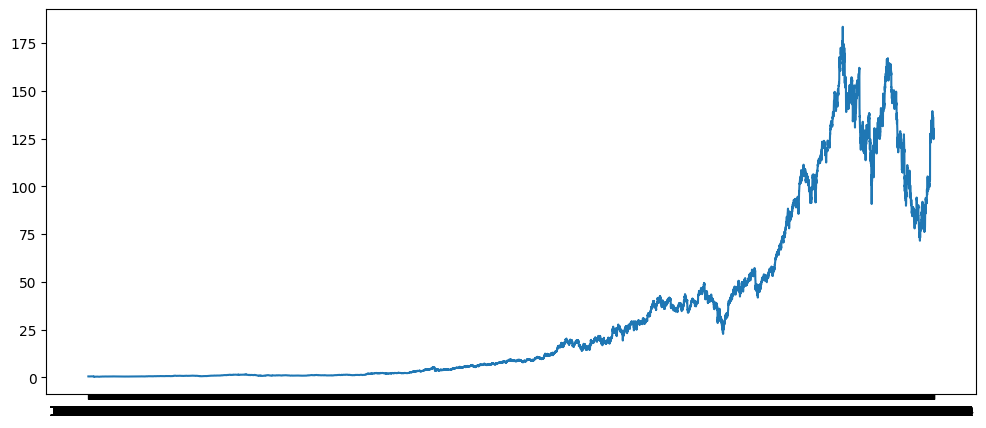

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_mmm["Date"], df_mmm["Close"])
plt.show()

#### From the above analysis we can see the prices are already adjusted for stock-splits

#### Calculate log-returns

In [19]:
import numpy as np

df_mmm['Log_Return'] = np.log(
    df_mmm['Close'] / df_mmm['Close'].shift(1)
)
df_mmm = df_mmm.dropna()

In [20]:
from scipy.stats import zscore

df_mmm['Z'] = zscore(df_mmm['Log_Return'])

outliers = df_mmm[df_mmm['Z'].abs() > 4]
print(outliers)

             Date Ticker        Open        High         Low       Close  \
99     1962-05-23    MMM    0.000000    0.490092    0.462201    0.462201   
102    1962-05-28    MMM    0.000000    0.450247    0.400441    0.401437   
103    1962-05-29    MMM    0.000000    0.462201    0.430325    0.460209   
124    1962-06-28    MMM    0.000000    0.379523    0.362589    0.376534   
206    1962-10-24    MMM    0.000000    0.382511    0.350635    0.382511   
...           ...    ...         ...         ...         ...         ...   
15268  2022-08-26    MMM  120.100334  120.409698  107.591972  107.976585   
15370  2023-01-24    MMM   97.023415  100.334450   95.735786   96.153847   
15460  2023-06-02    MMM   80.351173   87.416389   80.301003   85.727425   
15620  2024-01-23    MMM   84.331100   84.331100   78.687294   80.351173   
15748  2024-07-26    MMM  112.690002  128.029999  112.690002  127.160004   

           Volume  Dividends  Stock Splits    Return  Log_Return          Z  
99       

## Descriptive Analysis

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date to datetime
df_mmm['Date'] = pd.to_datetime(df_mmm['Date'])

# Sort chronologically
df_mmm = df_mmm.sort_values('Date')

# Set Date as index
df_mmm = df_mmm.set_index('Date')

#### Daily closing trend

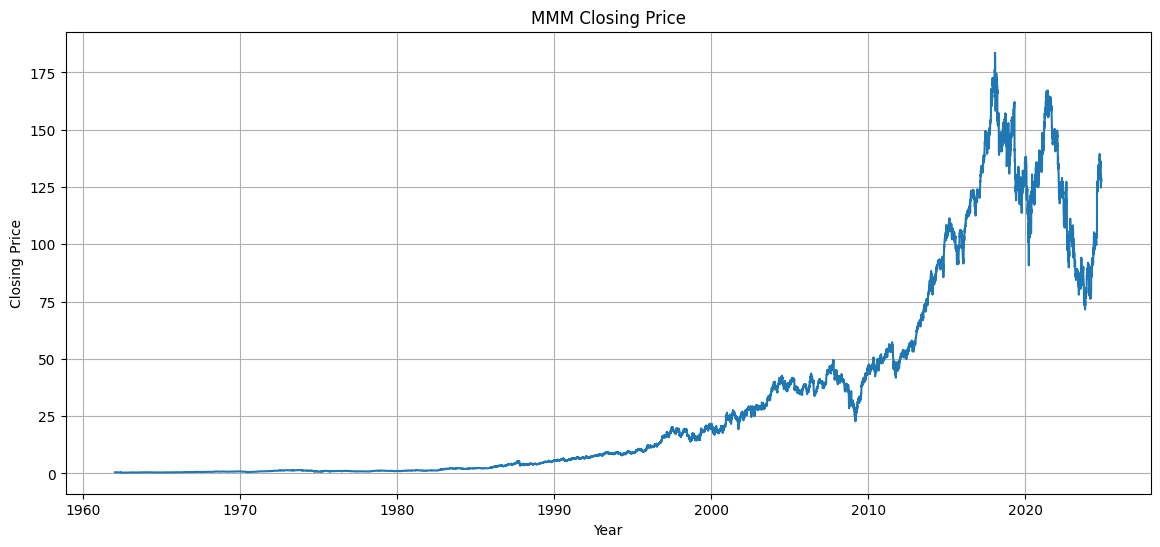

In [22]:
plt.figure(figsize=(14,6))
plt.plot(df_mmm.index, df_mmm['Close'])

plt.title("MMM Closing Price")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()



#### Monthly Averages - daily prices are too noisy. monthly averages reveal trend

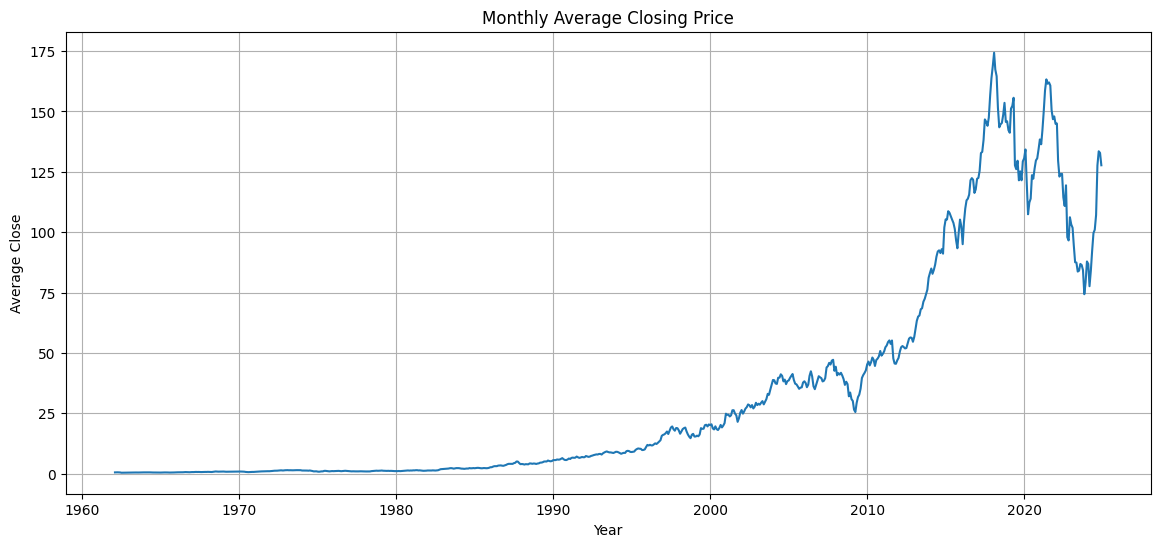

In [23]:
monthly_avg = df_mmm['Close'].resample('ME').mean()

plt.figure(figsize=(14,6))

plt.plot(monthly_avg)

plt.title("Monthly Average Closing Price")
plt.xlabel("Year")
plt.ylabel("Average Close")

plt.grid(True)

plt.show()

#### Yearly average prices

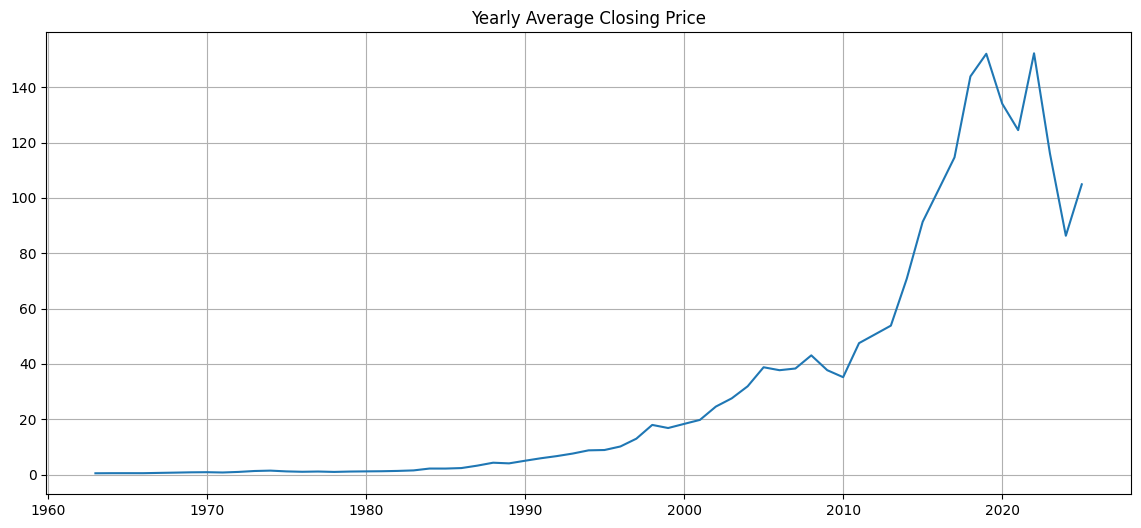

In [24]:
yearly_avg = df_mmm['Close'].resample('YE').mean()

plt.figure(figsize=(14,6))

plt.plot(yearly_avg)

plt.title("Yearly Average Closing Price")

plt.grid(True)

plt.show()

#### Year-over-year growth

Date
1962-12-31          NaN
1963-12-31    21.933995
1964-12-31   -14.313375
1965-12-31    22.799173
1966-12-31    14.705845
                ...    
2020-12-31     3.508294
2021-12-31     5.497736
2022-12-31   -31.706896
2023-12-31    -8.839227
2024-12-31    40.255400
Freq: YE-DEC, Name: Close, Length: 63, dtype: float64


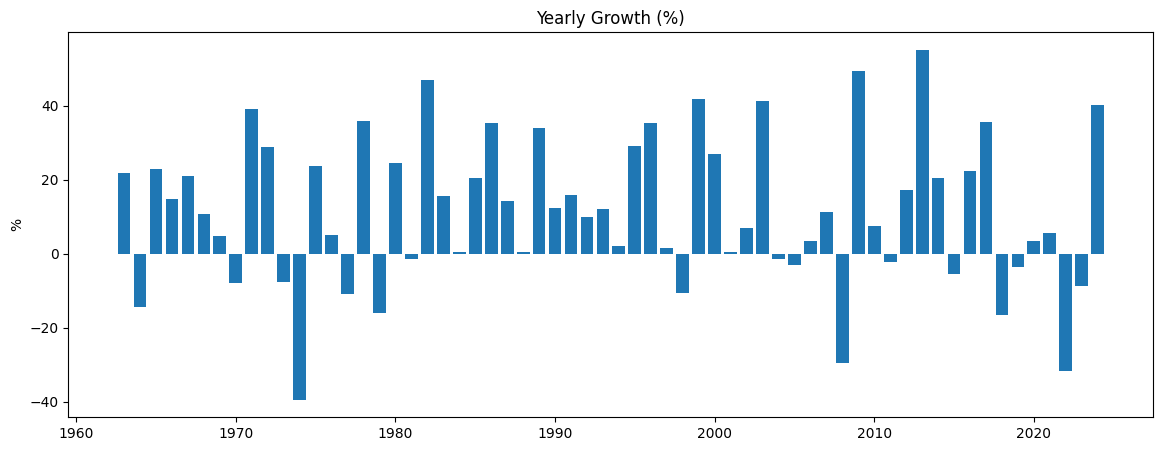

In [25]:
year_end = df_mmm['Close'].resample('YE').last()

yearly_growth = year_end.pct_change()*100

print(yearly_growth)

plt.figure(figsize=(14,5))

plt.bar(yearly_growth.index.year,
        yearly_growth.values)

plt.title("Yearly Growth (%)")
plt.ylabel("%")

plt.show()

#### 100 day moving average

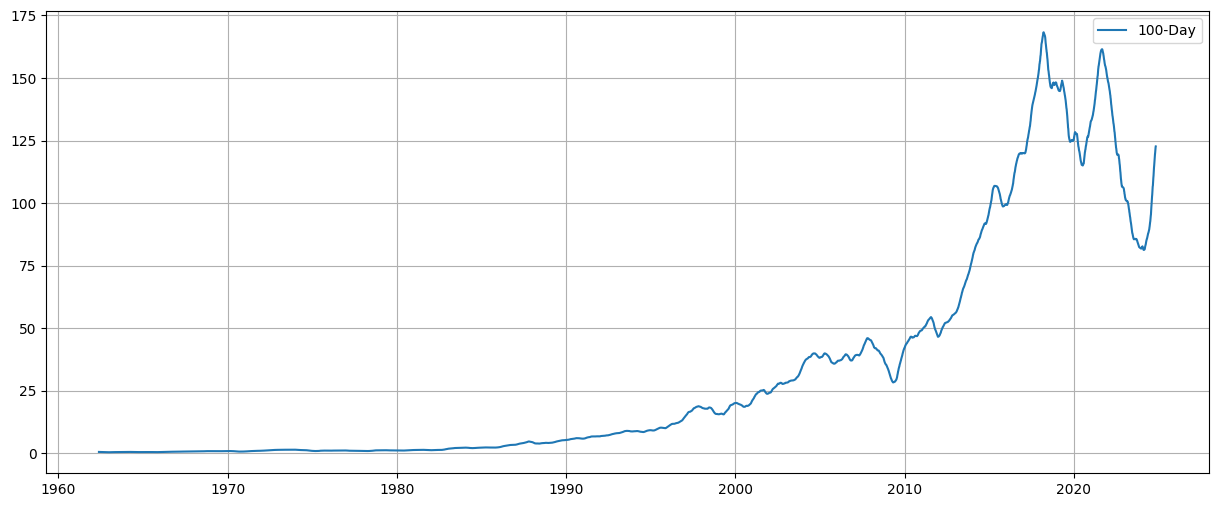

In [26]:
df_mmm['MA100'] = df_mmm['Close'].rolling(100).mean()

plt.figure(figsize=(15,6))

plt.plot(df_mmm['MA100'],
         label='100-Day')

plt.legend()

plt.grid(True)

plt.show()

#### Log-scale price chart -> A normal chart exaggerates recent movements because prices increase over decades.Equal percentage moves appear equal.Better for comparing growth over long periods.

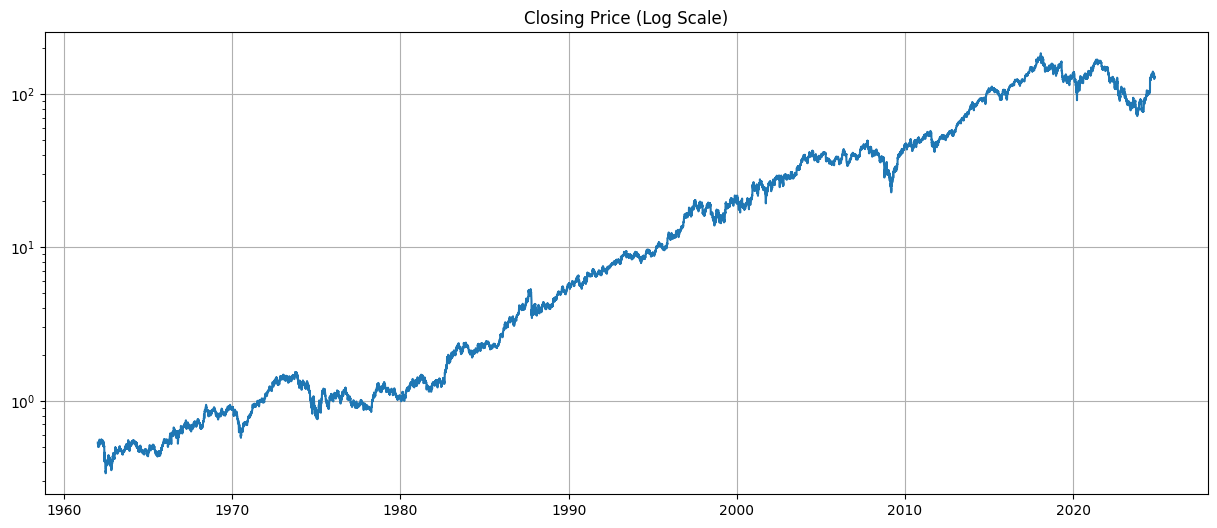

In [27]:
plt.figure(figsize=(15,6))

plt.plot(df_mmm['Close'])

plt.yscale('log')

plt.title("Closing Price (Log Scale)")

plt.grid(True)

plt.show()

## Return and Risk Analysis

In [28]:
print(df_mmm['Return'].describe())
mean_return = df_mmm['Return'].mean()

median_return = df_mmm['Return'].median()

std_return = df_mmm['Return'].std()

print(mean_return)
print(median_return)
print(std_return)

count    15818.000000
mean         0.000456
std          0.014776
min         -0.202847
25%         -0.007014
50%          0.000000
75%          0.007873
max          0.229906
Name: Return, dtype: float64
0.0004561710031611927
0.0
0.014775839506744435


#### Annualized return - assuming 252 trading days

In [29]:
annual_return = (
    (1 + mean_return)**252 - 1
)

print(f"{annual_return:.2%}")

12.18%


#### Annualized volatility

In [30]:
annual_volatility = std_return * np.sqrt(252)

print(f"{annual_volatility:.2%}")

23.46%


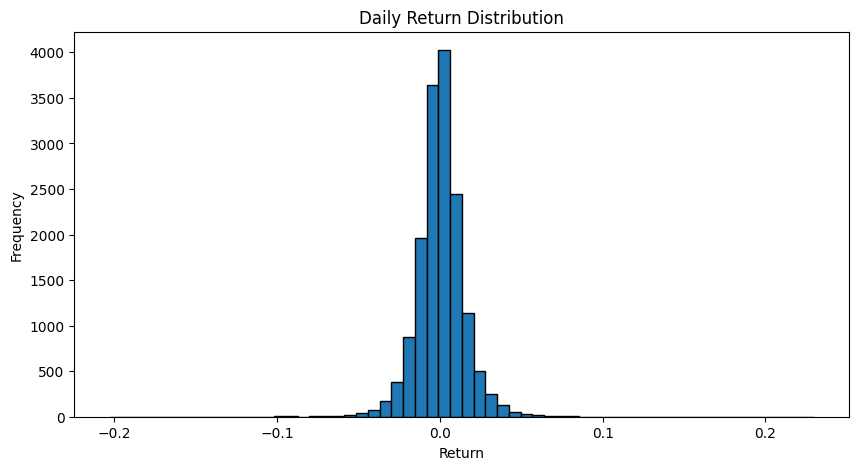

In [31]:
plt.figure(figsize=(10,5))

plt.hist(
    df_mmm['Return'],
    bins=60,
    edgecolor='black'
)

plt.title("Daily Return Distribution")

plt.xlabel("Return")

plt.ylabel("Frequency")

plt.show()

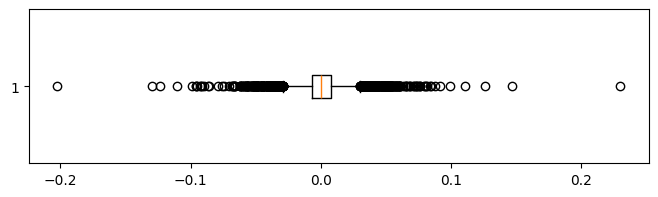

In [32]:
plt.figure(figsize=(8,2))

plt.boxplot(df_mmm['Return'],
            vert=False)

plt.show()

In [33]:
print(df_mmm['Return'].kurt())

11.253237758715109


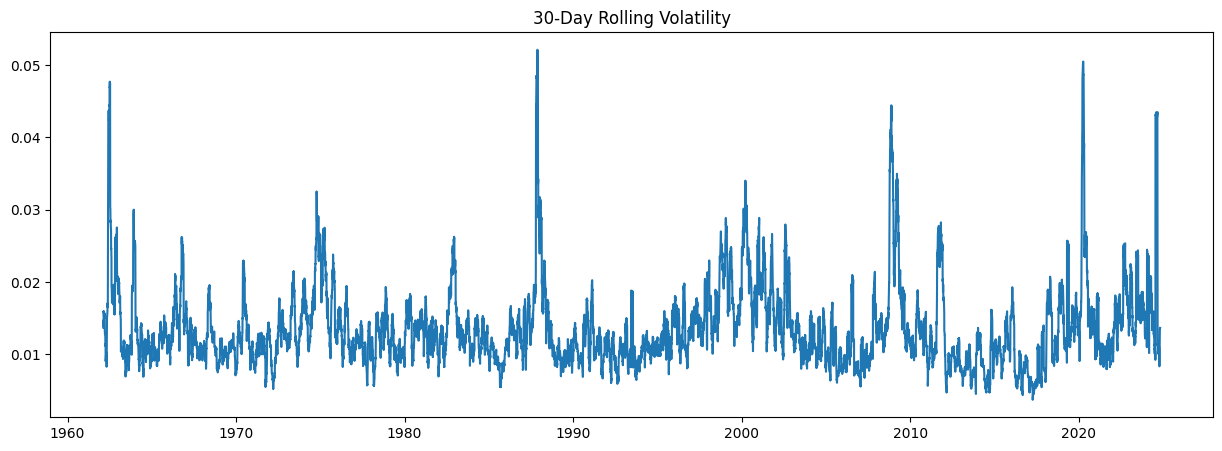

In [34]:
df_mmm['RollingVol30'] = (
    df_mmm['Return']
          .rolling(30)
          .std()
)

plt.figure(figsize=(15,5))

plt.plot(df_mmm['RollingVol30'])

plt.title("30-Day Rolling Volatility")

plt.show()

#### Cumulative return

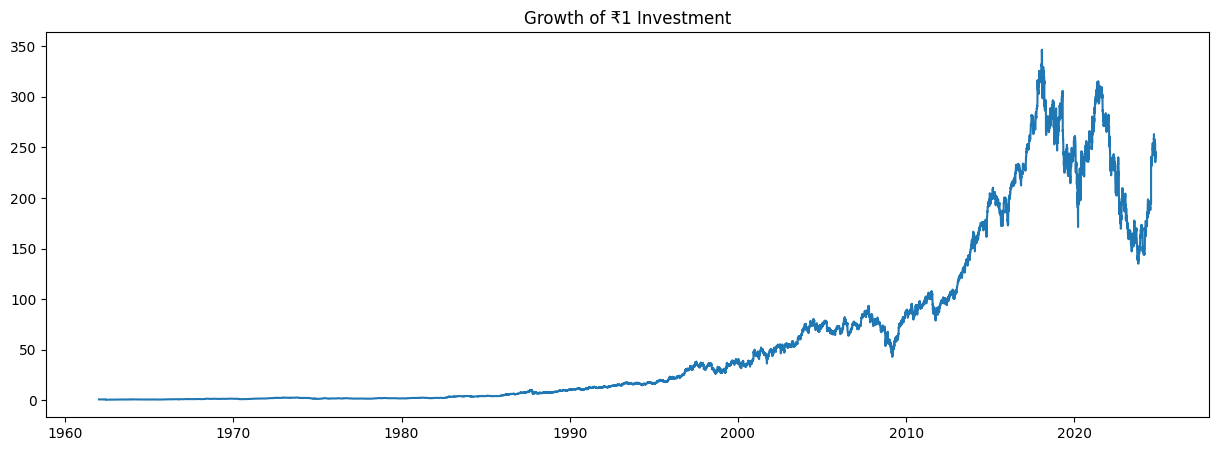

In [35]:
df_mmm['Cumulative_Return'] = (
    1 + df_mmm['Return']
).cumprod()

plt.figure(figsize=(15,5))

plt.plot(df_mmm['Cumulative_Return'])

plt.title("Growth of ₹1 Investment")

plt.show()

#### Running maximum and drawdown

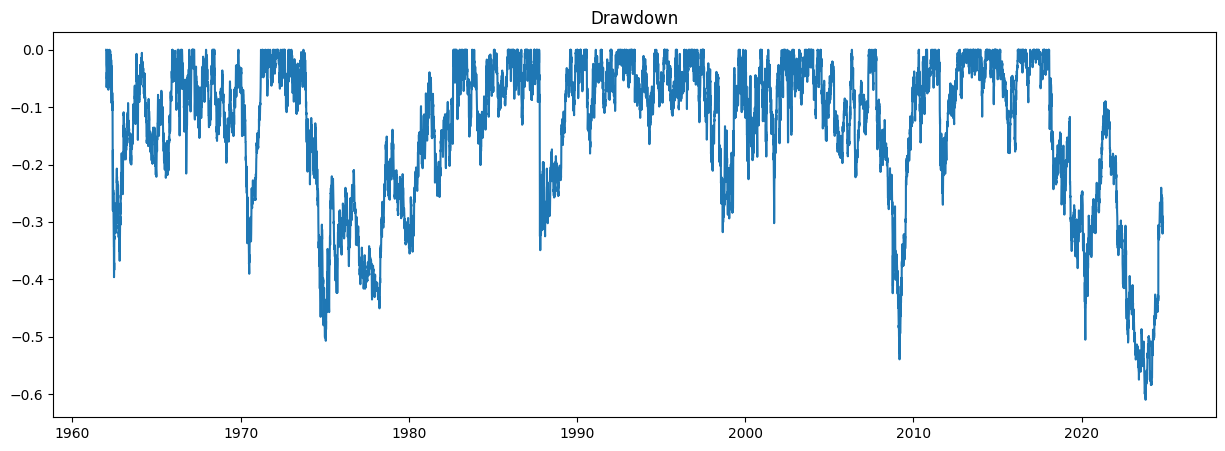

In [36]:
df_mmm['Running_Max'] = (
    df_mmm['Cumulative_Return']
    .cummax()
)
df_mmm['Drawdown'] = (
    df_mmm['Cumulative_Return']
    - df_mmm['Running_Max']
) / df_mmm['Running_Max']

plt.figure(figsize=(15,5))

plt.plot(df_mmm['Drawdown'])

plt.title("Drawdown")

plt.show()

#### Sharpe Ratio

In [37]:
sharpe = (
    annual_return
    /
    annual_volatility
)

print(sharpe)

0.5192448824253196


#### Sortino ratio

In [38]:
# Annualized return
annual_return = df_mmm['Return'].mean() * 252

# Risk-free rate (change if desired)
risk_free_rate = 0.00

# Downside returns only
downside_returns = df_mmm.loc[
    df_mmm['Return'] < 0,
    'Return'
]

# Annualized downside deviation
downside_std = downside_returns.std() * np.sqrt(252)

# Sortino Ratio
sortino_ratio = (annual_return - risk_free_rate) / downside_std

print(f"Sortino Ratio: {sortino_ratio:.3f}")

Sortino Ratio: 0.698


#### Maximum drawdown

In [39]:
# Growth of $1
df_mmm['Cumulative_Return'] = (
    1 + df_mmm['Return']
).cumprod()

# Running maximum
df_mmm['Running_Max'] = (
    df_mmm['Cumulative_Return']
).cummax()

# Drawdown
df_mmm['Drawdown'] = (
    df_mmm['Cumulative_Return']
    - df_mmm['Running_Max']
) / df_mmm['Running_Max']

# Maximum Drawdown
max_drawdown = df_mmm['Drawdown'].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -61.02%


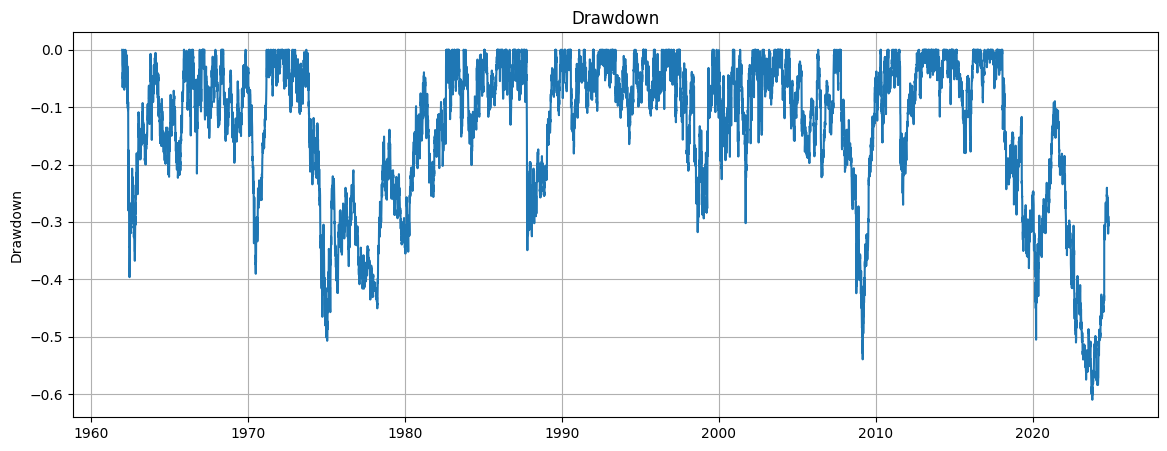

In [40]:
plt.figure(figsize=(14,5))

plt.plot(df_mmm.index,
         df_mmm['Drawdown'])

plt.title("Drawdown")
plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

#### Value-at-Risk

In [41]:
confidence = 0.95

VaR_95 = np.percentile(
    df_mmm['Return'],
    (1-confidence)*100
)

print(f"95% Daily VaR: {VaR_95:.2%}")

95% Daily VaR: -2.16%


#### Conditional VAR

In [42]:
CVaR_95 = df_mmm.loc[
    df_mmm['Return'] <= VaR_95,
    'Return'
].mean()

print(f"95% CVaR: {CVaR_95:.2%}")

95% CVaR: -3.28%


## Monte Carlo Simulations

#### We will use geometric brownian motion simulation

#### Estimate parameters

In [43]:
# Daily log returns
log_returns = np.log(
    df_mmm['Close'] /
    df_mmm['Close'].shift(1)
).dropna()

mu = log_returns.mean()

sigma = log_returns.std()

#### Set simulation parameters

In [44]:
S0 = df_mmm['Close'].iloc[-1]

T = 252              # one trading year

N = 10000            # simulations

dt = 1/252

#### Simulate

In [45]:
simulations = np.zeros((T, N))

simulations[0] = S0

for i in range(1, T):

    Z = np.random.standard_normal(N)

    simulations[i] = (
        simulations[i-1]
        * np.exp(
            (mu - 0.5*sigma**2)*dt
            + sigma*np.sqrt(dt)*Z
        )
    )

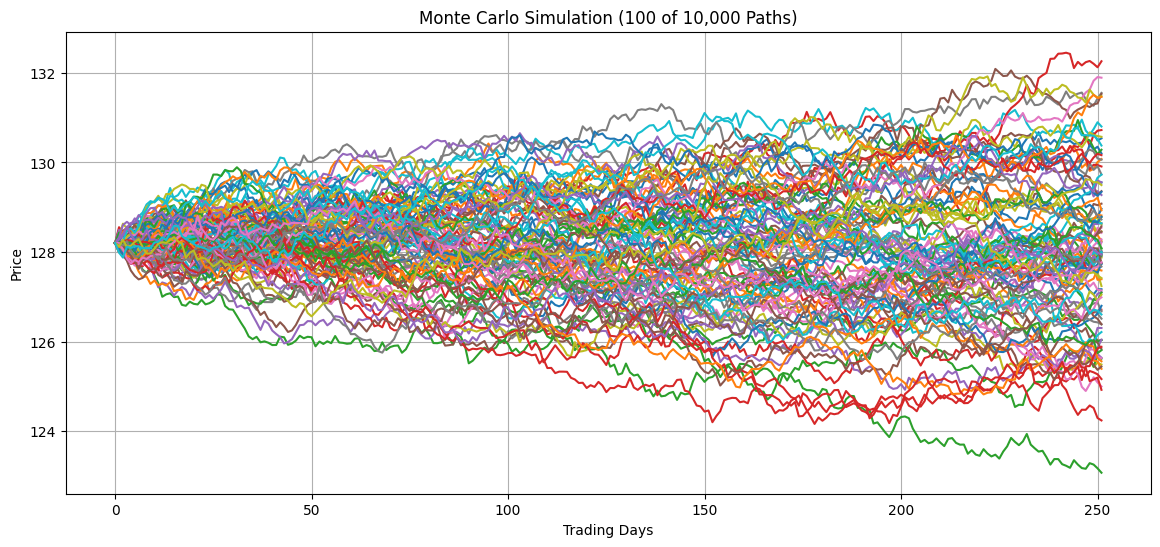

In [46]:
plt.figure(figsize=(14,6))

plt.plot(simulations[:, :100])

plt.title("Monte Carlo Simulation (100 of 10,000 Paths)")
plt.xlabel("Trading Days")
plt.ylabel("Price")

plt.grid(True)

plt.show()

#### Distribution of final prices

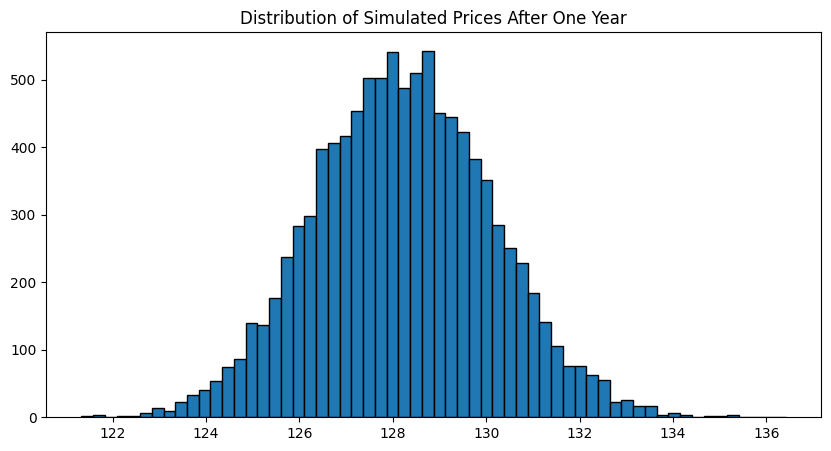

In [47]:
final_prices = simulations[-1]

plt.figure(figsize=(10,5))

plt.hist(final_prices,
         bins=60,
         edgecolor='black')

plt.title("Distribution of Simulated Prices After One Year")

plt.show()

#### Statistics

In [48]:
print(f"Current Price : {S0:.2f}")

print(f"Mean Final Price : {np.mean(final_prices):.2f}")

print(f"Median Final Price : {np.median(final_prices):.2f}")

print(f"Minimum : {np.min(final_prices):.2f}")

print(f"Maximum : {np.max(final_prices):.2f}")

print(f"5th Percentile : {np.percentile(final_prices,5):.2f}")

print(f"95th Percentile : {np.percentile(final_prices,95):.2f}")

Current Price : 128.20
Mean Final Price : 128.22
Median Final Price : 128.20
Minimum : 121.33
Maximum : 136.42
5th Percentile : 125.14
95th Percentile : 131.35


#### Probability of profit, Probablity of losing more than 20%

In [49]:
prob_profit = np.mean(final_prices > S0)

print(f"Probability of Profit: {prob_profit:.2%}")

prob_loss20 = np.mean(final_prices < 0.8*S0)

print(f"Probability of >20% Loss: {prob_loss20:.2%}")

Probability of Profit: 50.00%
Probability of >20% Loss: 0.00%


## Technical Indicator Analysis

### Trend Indicators

#### Simple Moving Averages

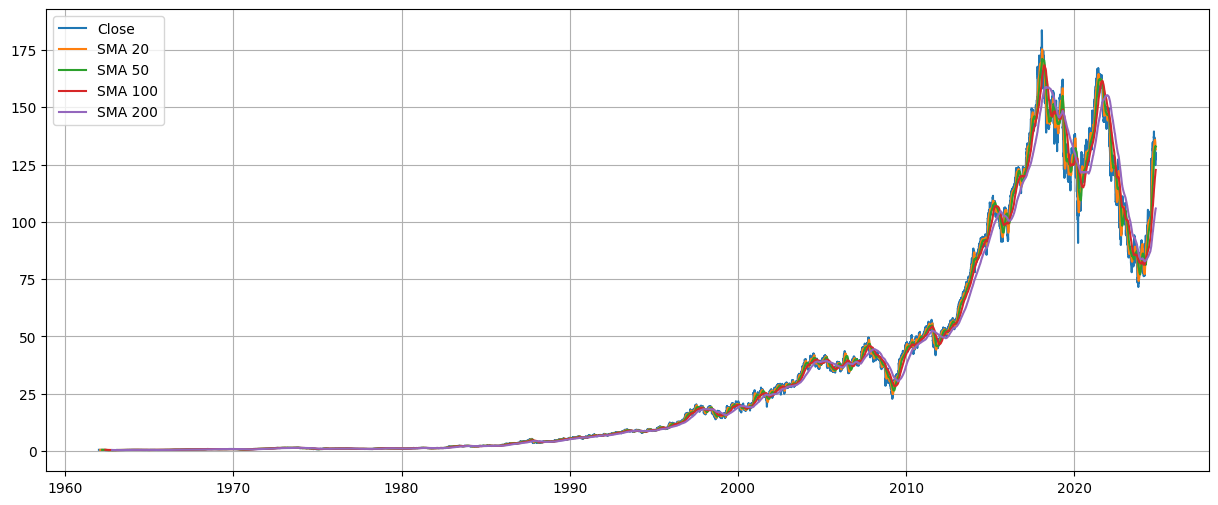

In [50]:
for period in [20, 50, 100, 200]:
    df_mmm[f'SMA_{period}'] = (
        df_mmm['Close']
        .rolling(window=period)
        .mean()
    )

plt.figure(figsize=(15,6))

plt.plot(df_mmm['Close'], label='Close')

for period in [20,50,100,200]:
    plt.plot(df_mmm[f'SMA_{period}'],
             label=f'SMA {period}')

plt.legend()

plt.grid(True)

plt.show()

#### Exponential Moving Averages

In [51]:
df_mmm['EMA_12'] = (
    df_mmm['Close']
    .ewm(span=12, adjust=False)
    .mean()
)

df_mmm['EMA_26'] = (
    df_mmm['Close']
    .ewm(span=26, adjust=False)
    .mean()
)

### Momentum Indicators

#### RSI (Relative Strength Index)

In [52]:
delta = df_mmm['Close'].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

RS = avg_gain / avg_loss

df_mmm['RSI'] = 100 - (100/(1+RS))

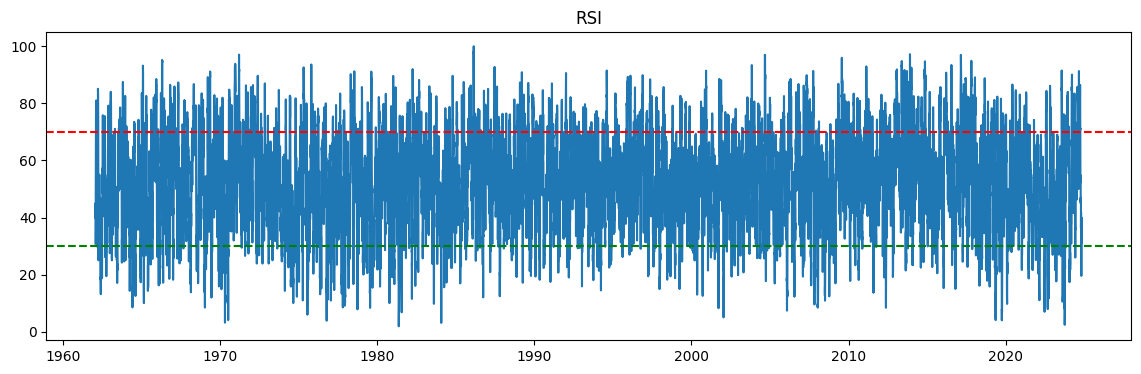

In [53]:
plt.figure(figsize=(14,4))

plt.plot(df_mmm['RSI'])

plt.axhline(70,
            color='red',
            linestyle='--')

plt.axhline(30,
            color='green',
            linestyle='--')

plt.title("RSI")

plt.show()

#### MACD

In [54]:
EMA12 = df_mmm['Close'].ewm(span=12,
                            adjust=False).mean()

EMA26 = df_mmm['Close'].ewm(span=26,
                            adjust=False).mean()

df_mmm['MACD'] = EMA12 - EMA26

df_mmm['Signal'] = (
    df_mmm['MACD']
    .ewm(span=9,
         adjust=False)
    .mean()
)

df_mmm['Histogram'] = (
    df_mmm['MACD']
    - df_mmm['Signal']
)

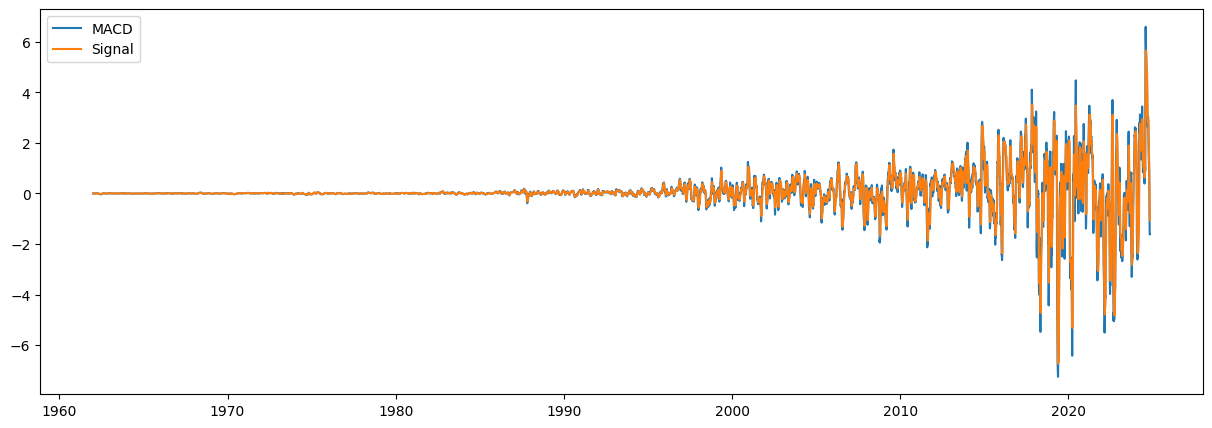

In [55]:
plt.figure(figsize=(15,5))

plt.plot(df_mmm['MACD'],
         label='MACD')

plt.plot(df_mmm['Signal'],
         label='Signal')

plt.legend()

plt.show()

### Volatility Indicators

#### Bollinger Bands

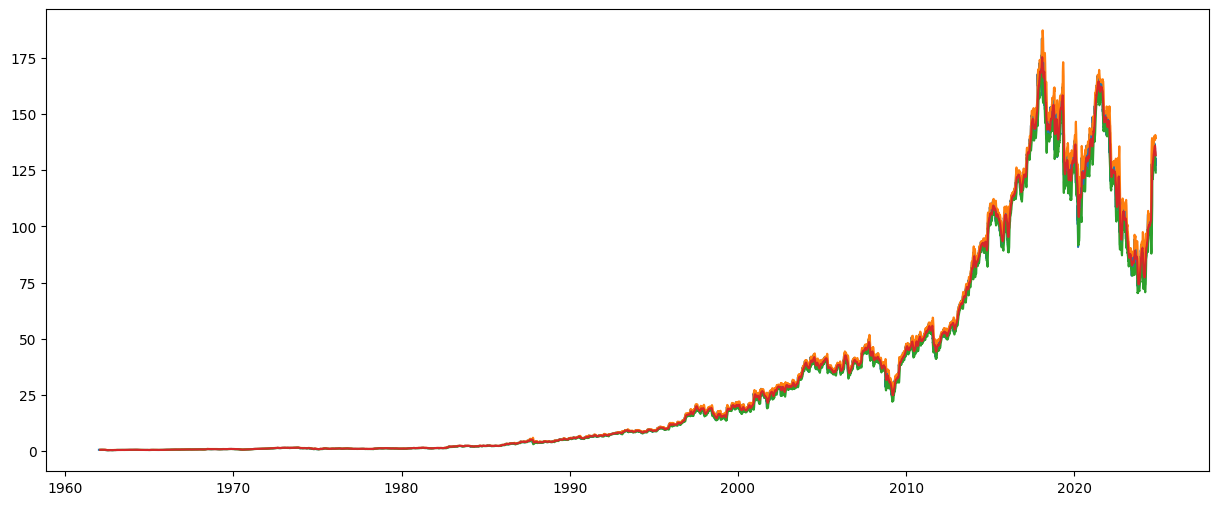

In [57]:
SMA20 = df_mmm['Close'].rolling(20).mean()

STD20 = df_mmm['Close'].rolling(20).std()

df_mmm['BB_Upper'] = SMA20 + 2*STD20

df_mmm['BB_Lower'] = SMA20 - 2*STD20

df_mmm['BB_Middle'] = SMA20

plt.figure(figsize=(15,6))

plt.plot(df_mmm['Close'])

plt.plot(df_mmm['BB_Upper'])

plt.plot(df_mmm['BB_Lower'])

plt.plot(df_mmm['BB_Middle'])

plt.show()

#### Average True Range

In [58]:
TR1 = df_mmm['High'] - df_mmm['Low']

TR2 = abs(
    df_mmm['High']
    - df_mmm['Close'].shift()
)

TR3 = abs(
    df_mmm['Low']
    - df_mmm['Close'].shift()
)

In [59]:
TR = pd.concat(
    [TR1,TR2,TR3],
    axis=1
).max(axis=1)

In [60]:
df_mmm['ATR'] = (
    TR
    .rolling(14)
    .mean()
)

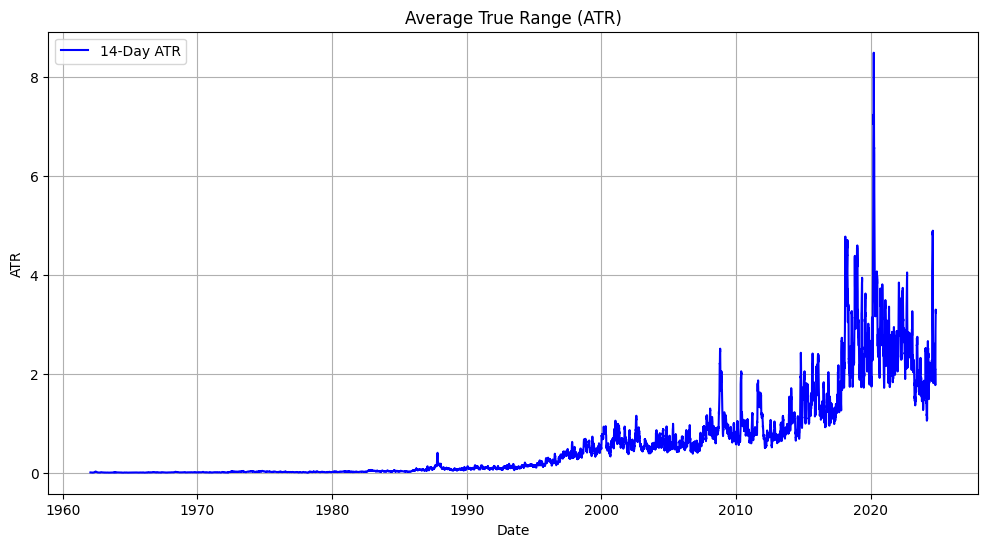

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_mmm.index, df_mmm['ATR'], label='14-Day ATR', color='blue')

plt.title('Average True Range (ATR)')
plt.xlabel('Date')
plt.ylabel('ATR')
plt.legend()
plt.grid(True)

plt.show()

### Volume Indicator

#### On Balance Volume

In [62]:
OBV = [0]

for i in range(1,len(df_mmm)):

    if df_mmm['Close'].iloc[i] > df_mmm['Close'].iloc[i-1]:

        OBV.append(
            OBV[-1] + df_mmm['Volume'].iloc[i]
        )

    elif df_mmm['Close'].iloc[i] < df_mmm['Close'].iloc[i-1]:

        OBV.append(
            OBV[-1] - df_mmm['Volume'].iloc[i]
        )

    else:

        OBV.append(
            OBV[-1]
        )

df_mmm['OBV'] = OBV

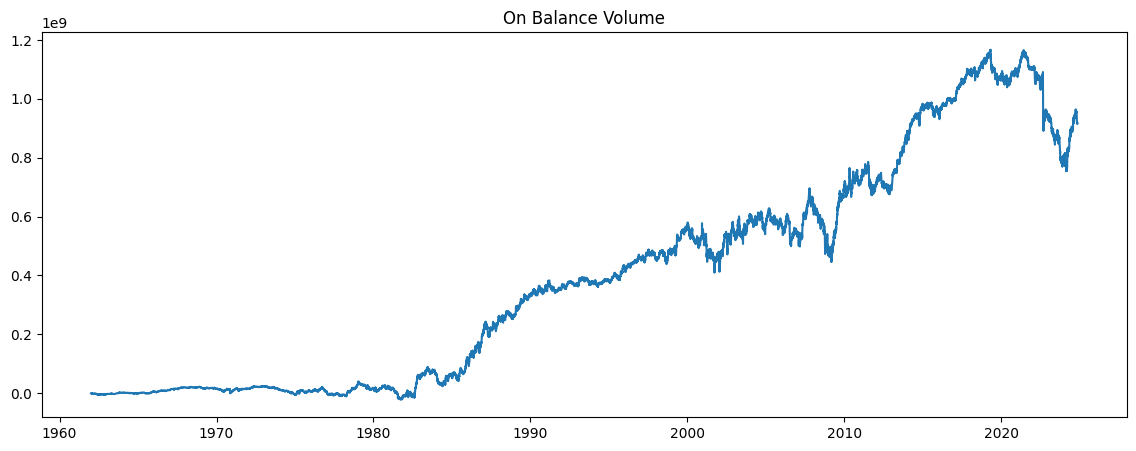

In [63]:
plt.figure(figsize=(14,5))

plt.plot(df_mmm['OBV'])

plt.title("On Balance Volume")

plt.show()

## Comparing Monte Carlo Simulations against historic data
#### Validate whether simulation could have predicted future prices - let us pretend we are at end of 2020

In [65]:
# Training data
train = df_mmm.loc[:'2020-12-31'].copy()

# Actual future data
test = df_mmm.loc['2021-01-01':'2021-12-31'].copy()

#### Estimate GBM parameters

In [66]:
log_returns = np.log(
    train['Close'] /
    train['Close'].shift(1)
).dropna()

mu = log_returns.mean()
sigma = log_returns.std()

In [67]:
S0 = train['Close'].iloc[-1]

In [68]:
T = len(test)

dt = 1/252

N = 10000

#### Actaul Monte Carlo Simulations

In [69]:
simulations = np.zeros((T, N))

simulations[0] = S0

for t in range(1, T):

    Z = np.random.standard_normal(N)

    simulations[t] = (
        simulations[t-1]
        * np.exp(
            (mu - 0.5*sigma**2)*dt
            + sigma*np.sqrt(dt)*Z
        )
    )

In [70]:
mean_path = simulations.mean(axis=1)

median_path = np.median(simulations, axis=1)

#95 % interval
lower95 = np.percentile(simulations, 2.5, axis=1)

upper95 = np.percentile(simulations, 97.5, axis=1)

#90 % interval
lower90 = np.percentile(simulations, 5, axis=1)

upper90 = np.percentile(simulations, 95, axis=1)

#### Compare with actual prices

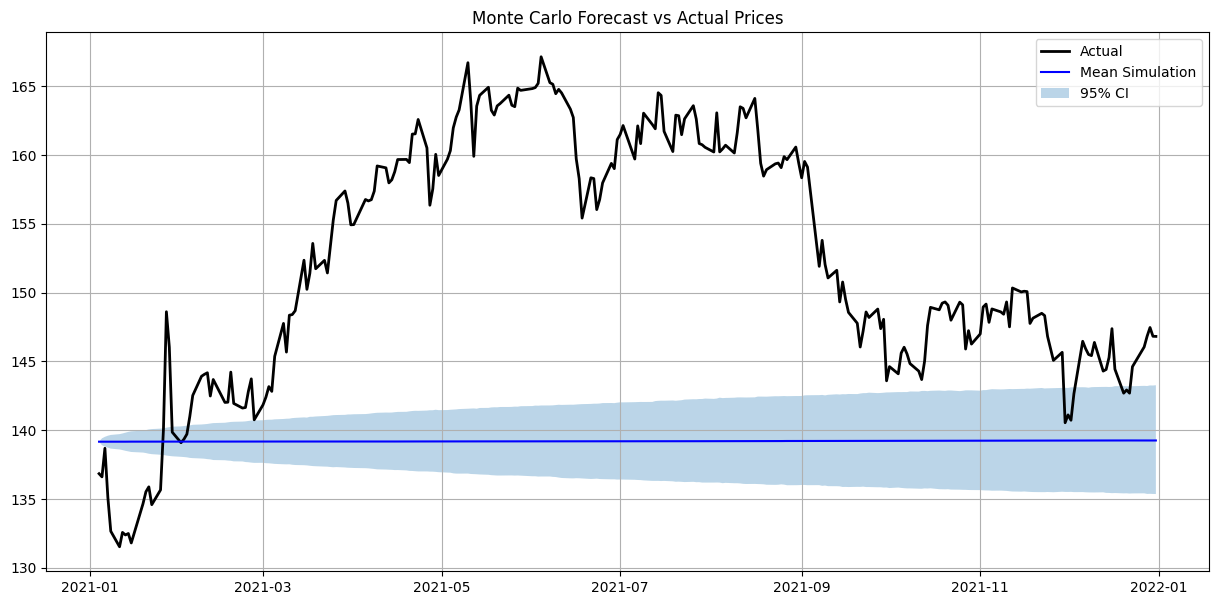

In [71]:
actual = test['Close'].values

plt.figure(figsize=(15,7))

plt.plot(
    test.index,
    actual,
    color='black',
    linewidth=2,
    label='Actual'
)

plt.plot(
    test.index,
    mean_path,
    color='blue',
    label='Mean Simulation'
)

plt.fill_between(
    test.index,
    lower95,
    upper95,
    alpha=0.3,
    label='95% CI'
)

plt.legend()

plt.title("Monte Carlo Forecast vs Actual Prices")

plt.grid(True)

plt.show()

#### Prediction Error

In [72]:
mae = np.mean(
    np.abs(actual - mean_path)
)

print("MAE:", mae)

rmse = np.sqrt(
    np.mean(
        (actual - mean_path)**2
    )
)

print("RMSE:", rmse)

mape = np.mean(
    np.abs(
        (actual - mean_path)
        / actual
    )
)*100

print(f"MAPE = {mape:.2f}%")

MAE: 13.624419116749138
RMSE: 15.805228641559186
MAPE = 8.68%


### Coverage Probablity

In [75]:
inside95 = (
    (actual >= lower95)
    &
    (actual <= upper95)
)

In [76]:
coverage95 = inside95.mean()*100

print(f"95% Coverage = {coverage95:.2f}%")

95% Coverage = 4.76%


In [77]:
print("Actual Final Price")

print(actual[-1])

print()

print("Predicted Mean")

print(mean_path[-1])

print()

print("Predicted Median")

print(median_path[-1])

print()

print("95% Interval")

print(lower95[-1])

print(upper95[-1])

Actual Final Price
146.81944274902344

Predicted Mean
139.25714632572192

Predicted Median
139.24338512921767

95% Interval
135.36527814828705
143.27015313734867


#### Was final price within confidence interval?

In [78]:
if lower95[-1] <= actual[-1] <= upper95[-1]:
    print("Final price lies inside 95% confidence interval.")
else:
    print("Final price lies outside 95% confidence interval.")

Final price lies outside 95% confidence interval.


In [81]:
print("="*40)

print("MODEL VALIDATION")

print("="*40)

print(f"Training Period : {train.index[0].date()} to {train.index[-1].date()}")

print(f"Testing Period  : {test.index[0].date()} to {test.index[-1].date()}")

print(f"Simulations     : {N}")

print(f"MAE             : {mae:.2f}")

print(f"RMSE            : {rmse:.2f}")

print(f"MAPE            : {mape:.2f}%")

print(f"95% Coverage    : {coverage95:.2f}%")

MODEL VALIDATION
Training Period : 1962-01-03 to 2020-12-31
Testing Period  : 2021-01-04 to 2021-12-31
Simulations     : 10000
MAE             : 13.62
RMSE            : 15.81
MAPE            : 8.68%
95% Coverage    : 4.76%


### Why such poor coverage?

GBM assumes:

1. Constant volatility
2. Constant drift
3. Normally distributed log returns
4. Independent returns

Real markets violate all of these assumptions.

The Monte Carlo simulation based on Geometric Brownian Motion produced reasonable average price forecasts (MAPE ≈ 8.7%). However, the simulated confidence intervals failed to capture the realized price path, with only 4.76% of observations falling within the nominal 95% confidence band. This suggests that the assumptions of constant drift, constant volatility, and log-normal returns were inadequate for the validation period. More sophisticated approaches such as historical bootstrap simulations, GARCH-based volatility models, or jump-diffusion processes may provide better uncertainty estimates.